In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("ETTm1.csv")

df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 00:15:00,5.760,2.076,1.492,0.426,4.264,1.401,30.459999
2,2016-07-01 00:30:00,5.760,1.942,1.492,0.391,4.234,1.310,30.038000
3,2016-07-01 00:45:00,5.760,1.942,1.492,0.426,4.234,1.310,27.013000
4,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001


In [3]:
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 69680 entries, 0 to 69679
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    69680 non-null  str    
 1   HUFL    69680 non-null  float64
 2   HULL    69680 non-null  float64
 3   MUFL    69680 non-null  float64
 4   MULL    69680 non-null  float64
 5   LUFL    69680 non-null  float64
 6   LULL    69680 non-null  float64
 7   OT      69680 non-null  float64
dtypes: float64(7), str(1)
memory usage: 5.5 MB


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,69680.000000,69680.000000,69680.000000,69680.000000,69680.000000,69680.000000,69680.000000
mean,7.413993,2.261418,4.322226,0.896509,3.082888,0.857907,13.320642
std,7.082928,2.041293,6.829189,1.807239,1.174063,0.600440,8.564817
min,-23.242001,-5.693000,-26.367001,-6.041000,-1.188000,-1.371000,-4.221000
25%,5.827000,0.804000,3.305000,-0.284000,2.315000,0.670000,6.964000
50%,8.841000,2.210000,6.005000,0.959000,2.833000,0.975000,11.396000
75%,11.788000,3.684000,8.635000,2.203000,3.655000,1.218000,18.079000
max,24.180000,10.315000,18.087000,7.853000,8.498000,3.046000,46.007000


In [4]:
df_numeric = df.drop(columns=['date'])

df_numeric.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,5.760,2.076,1.492,0.426,4.264,1.401,30.459999
2,5.760,1.942,1.492,0.391,4.234,1.310,30.038000
3,5.760,1.942,1.492,0.426,4.234,1.310,27.013000
4,5.693,2.076,1.492,0.426,4.142,1.371,27.787001


In [5]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_numeric)

scaled_data[:5]

array([[-0.22406053, -0.12365696, -0.39876566, -0.24042862,  0.9540541 ,
         0.80290435,  2.00943955],
       [-0.23351995, -0.09083444, -0.41443381, -0.26034866,  1.00601069,
         0.90449719,  2.00114964],
       [-0.23351995, -0.15647954, -0.41443381, -0.27971535,  0.98045844,
         0.75294049,  1.95187806],
       [-0.23351995, -0.15647954, -0.41443381, -0.26034866,  0.98045844,
         0.75294049,  1.59868647],
       [-0.24297944, -0.09083444, -0.41443381, -0.26034866,  0.90209752,
         0.85453354,  1.68905685]])

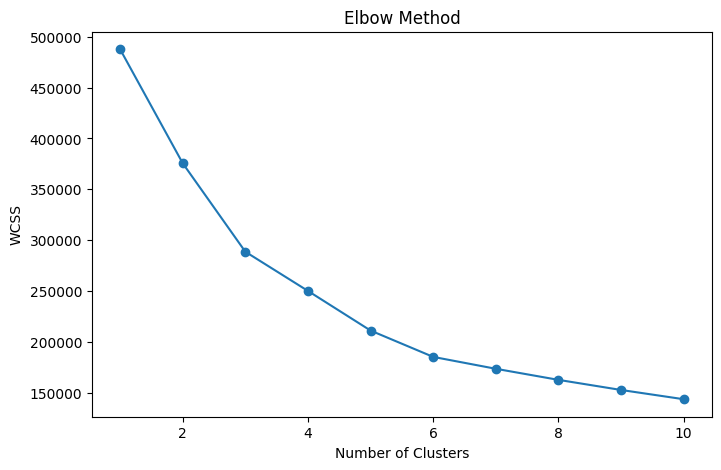

In [6]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,Cluster
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000,2
1,2016-07-01 00:15:00,5.760,2.076,1.492,0.426,4.264,1.401,30.459999,2
2,2016-07-01 00:30:00,5.760,1.942,1.492,0.391,4.234,1.310,30.038000,2
3,2016-07-01 00:45:00,5.760,1.942,1.492,0.426,4.234,1.310,27.013000,2
4,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001,2


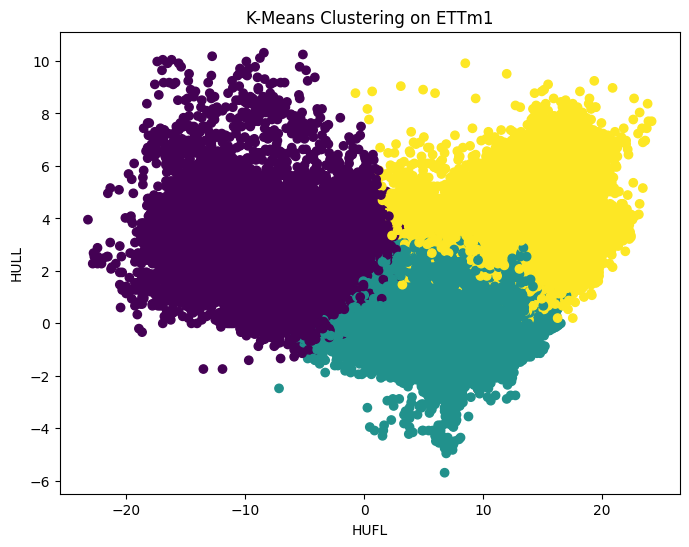

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(df['HUFL'], df['HULL'], c=df['Cluster'])

plt.xlabel("HUFL")
plt.ylabel("HULL")
plt.title("K-Means Clustering on ETTm1")

plt.show()

In [9]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(centers, columns=df_numeric.columns)

centers_df

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,-7.280879,2.963510,-10.329832,1.485701,3.015966,1.038716,12.915788
1,7.818399,0.663701,5.128304,-0.338445,2.639534,0.589523,11.014789
2,11.820529,3.879334,8.249253,2.131645,3.618681,1.108827,16.126104


In [10]:
df.to_csv("ETTm1_clustered.csv", index=False)